<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_9_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

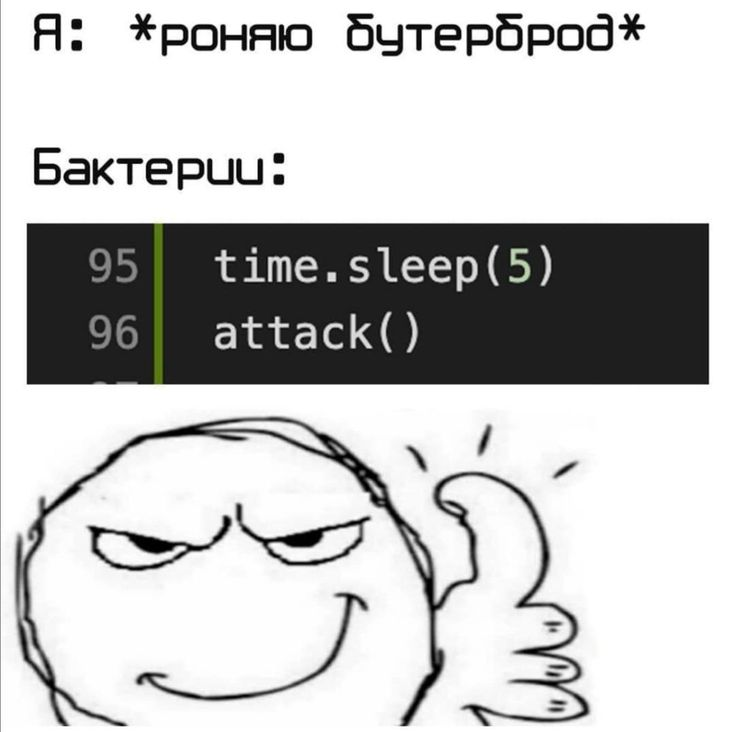

# Наибольшие общие префиксы

Для многих применений часто бывает полезным возможность находить длину **наибольшего общего префикса**(англ. largest common prefix) для различных суффиксов строки.

Например, чтобы просто сравнить две подстроки, мы можем найти наибольший префикс соответствующих суффиксов и посмотреть на следующий символ — так же, как это обычно делается хешами.

**Утверждение**. Пусть мы знаем $lcp$ для всех суффиксов, которые являются соседями в суффиксном массиве — это будет какой-то массив длины $(n−1)$. Тогда общий префикс для $i$-того и $j$-того суффикса будет равен минимуму между $c_i$-тым и $c_j$ -тым элементом в массиве lcp (напомним, что $c_i$
  — класс эквивалентности — это номер $i$-того суффикса в суффиксном массиве).
  


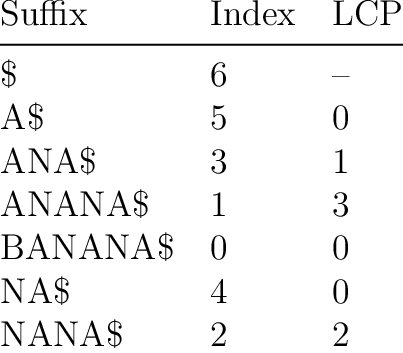

# Алгоритм Касаи, Аримуры, Арикавы, Ли, Парка

Алгоритм в реальности называется как угодно, но не исходным способом (алгоритм Касаи, алгоритм пяти корейцев, и т. д.). Используется для подсчета $lcp$ за линейное время.

**Утверждение**. Пусть мы уже построили суфмасс и посчитали $lcp[i]$. Тогда:
$lcp[c[p[i]+1]]≥lcp[i]−1$
По-русски: $lcp$ от следующего суффикса в исходной строке не более чем на единицу меньше.

**Доказательство**. Если для $p[i]$-го суффикса была общая часть длины $lcp[i]$ с $p[i+1]$-ым суффиксом, то у $(p[i]+1)$-го суффикса гарантированно будет общая часть длины $(lcp[i]−1)$ с $(p[i+1]+1)$-ым суффиксом.

Заметим, что этот суффикс уже не обязательно будет соседом $(p[i]+1)$-го в суффиксном массиве, но из свойства $lcp$ двух произвольных суффиксов получим, что $lcp[c[p[i]+1]]≥lcp[i]−1$. Здесь возникает идея просто считать точное значение $lcp$ наивным образом — увеличиваем, пока увеличивается — но брать его стартовое значение, опираясь на это неравенство. В таком случае, чтобы не делать лишние сравнения, будем считать также считать массив $lcp$ в порядке от длинных суффиксов к коротким.

### Описание алгоритма
Алгоритм Касаи (Kasai et al., 2001) вычисляет массив $LCP$ за линейное время $O(n)$, используя следующие ключевые идеи:

* **Обратный массив**: строится массив $rank$, где $rank[i]$ - позиция суффикса, начинающегося в позиции $i$, в суффиксном массиве.

* **Итеративный подсчет**: для каждого суффикса в порядке исходной строки вычисляется $LCP$ с следующим суффиксом в SA.

Свойство убывания: если $LCP$ между суффиксами $i$ и $j$ равен $h$, то $LCP$ между суффиксами $i+1$ и $j+1$ будет не меньше $h-1$. Это позволяет избежать повторных сравнений.

### Сложность
**Время**: $O(n)$ для построения $LCP$ массива после получения суффиксного массива

**Память**: $O(n)$ для хранения массивов $rank$ и $lcp$

In [1]:
def build_suffix_array(s):
    """
    Построение суффиксного массива за O(n log n) с помощью алгоритма удвоения.

    Args:
        s: входная строка

    Returns:
        suffix_array: список индексов, задающих порядок суффиксов
    """
    n = len(s)
    # Начальные ранги - коды символов
    k = 1
    rank = [ord(c) for c in s]
    tmp = [0] * n
    sa = list(range(n))

    while True:
        # Сортировка по (rank[i], rank[i+k]) с использованием ключа-кортежа
        sa.sort(key=lambda x: (rank[x], rank[x + k] if x + k < n else -1))

        # Пересчет рангов
        tmp[sa[0]] = 0
        for i in range(1, n):
            prev, cur = sa[i-1], sa[i]
            prev_key = (rank[prev], rank[prev + k] if prev + k < n else -1)
            cur_key = (rank[cur], rank[cur + k] if cur + k < n else -1)
            tmp[cur] = tmp[prev] + (prev_key != cur_key)

        rank[:] = tmp
        if rank[sa[-1]] == n - 1:
            break
        k <<= 1

    return sa

def build_lcp_array(s, sa):
    """
    Построение LCP массива с использованием алгоритма Касаи.

    Алгоритм вычисляет LCP (Longest Common Prefix) между соседними
    суффиксами в суффиксном массиве за линейное время O(n).

    Args:
        s: исходная строка
        sa: суффиксный массив

    Returns:
        lcp: массив, где lcp[i] = LCP(sa[i], sa[i+1]) для i = 0..n-2
    """
    n = len(s)
    rank = [0] * n

    # Построение обратного массива (позиция суффикса в суффиксном массиве)
    for i in range(n):
        rank[sa[i]] = i

    lcp = [0] * (n - 1)
    h = 0

    for i in range(n):
        # Если суффикс начинающийся с позиции i имеет ранг r,
        # то рассматриваем соседний суффикс в SA
        r = rank[i]
        if r == n - 1:
            h = 0
            continue

        # Индекс следующего суффикса в SA
        j = sa[r + 1]

        # Вычисление LCP между суффиксами i и j
        while i + h < n and j + h < n and s[i + h] == s[j + h]:
            h += 1

        lcp[r] = h

        # Уменьшаем h, если оно больше 0 (свойство: lcp следующей пары >= h-1)
        if h > 0:
            h -= 1

    return lcp

def kasai_algorithm(s, sa):
    """
    Реализация алгоритма Касаи, Аримуры, Арикавы, Ли, Парка.

    Args:
        s: исходная строка
        sa: суффиксный массив

    Returns:
        tuple: (суффиксный массив, LCP массив)
    """
    lcp = build_lcp_array(s, sa)
    return sa, lcp

# Пример использования и тестирования
if __name__ == "__main__":
    # Тест 1: Простая строка
    s1 = "banana"
    print(f"Строка: {s1}")

    # Построение суффиксного массива
    sa1 = build_suffix_array(s1)
    print(f"Суффиксный массив: {sa1}")

    # Вывод суффиксов в порядке сортировки
    print("Суффиксы в лексикографическом порядке:")
    for idx in sa1:
        print(f"  {idx}: {s1[idx:]}")

    # Построение LCP массива алгоритмом Касаи
    sa1, lcp1 = kasai_algorithm(s1, sa1)
    print(f"\nLCP массив: {lcp1}")
    print("LCP между соседними суффиксами:")
    for i in range(len(lcp1)):
        print(f"  lcp[{i}] = {lcp1[i]} (между {sa1[i]}: '{s1[sa1[i]:]}' и {sa1[i+1]}: '{s1[sa1[i+1]:]}')")

    print("\n" + "="*50 + "\n")

    # Тест 2: Другая строка
    s2 = "abracadabra"
    print(f"Строка: {s2}")

    sa2 = build_suffix_array(s2)
    print(f"Суффиксный массив: {sa2}")

    sa2, lcp2 = kasai_algorithm(s2, sa2)
    print(f"LCP массив: {lcp2}")

    # Проверка корректности для первых нескольких значений
    print("\nПроверка корректности LCP (первые 5 значений):")
    for i in range(min(5, len(lcp2))):
        # Вручную вычисляем LCP для проверки
        suffix1 = s2[sa2[i]:]
        suffix2 = s2[sa2[i+1]:]
        manual_lcp = 0
        while (manual_lcp < len(suffix1) and manual_lcp < len(suffix2) and
               suffix1[manual_lcp] == suffix2[manual_lcp]):
            manual_lcp += 1
        print(f"  lcp[{i}] = {lcp2[i]}, ручной расчет: {manual_lcp} ✓")

    print("\n" + "="*50 + "\n")

    # Тест 3: Строка с повторяющимися символами
    s3 = "aaaaa"
    print(f"Строка: {s3}")

    sa3 = build_suffix_array(s3)
    print(f"Суффиксный массив: {sa3}")

    sa3, lcp3 = kasai_algorithm(s3, sa3)
    print(f"LCP массив: {lcp3}")
    print("Ожидаемый LCP: [4, 3, 2, 1]")

Строка: banana
Суффиксный массив: [5, 3, 1, 0, 4, 2]
Суффиксы в лексикографическом порядке:
  5: a
  3: ana
  1: anana
  0: banana
  4: na
  2: nana

LCP массив: [1, 3, 0, 0, 2]
LCP между соседними суффиксами:
  lcp[0] = 1 (между 5: 'a' и 3: 'ana')
  lcp[1] = 3 (между 3: 'ana' и 1: 'anana')
  lcp[2] = 0 (между 1: 'anana' и 0: 'banana')
  lcp[3] = 0 (между 0: 'banana' и 4: 'na')
  lcp[4] = 2 (между 4: 'na' и 2: 'nana')


Строка: abracadabra
Суффиксный массив: [10, 7, 0, 3, 5, 8, 1, 4, 6, 9, 2]
LCP массив: [1, 4, 1, 1, 0, 3, 0, 0, 0, 2]

Проверка корректности LCP (первые 5 значений):
  lcp[0] = 1, ручной расчет: 1 ✓
  lcp[1] = 4, ручной расчет: 4 ✓
  lcp[2] = 1, ручной расчет: 1 ✓
  lcp[3] = 1, ручной расчет: 1 ✓
  lcp[4] = 0, ручной расчет: 0 ✓


Строка: aaaaa
Суффиксный массив: [4, 3, 2, 1, 0]
LCP массив: [1, 2, 3, 4]
Ожидаемый LCP: [4, 3, 2, 1]


# Быстрое преобразование Фурье (БПФ == FFT)

Здесь мы рассмотрим алгоритм, который позволяет перемножить два полинома длиной $n$ за время $O(n \log n)$, что значительно лучше времени $O(n^2)$, достигаемого тривиальным алгоритмом умножения. Очевидно, что умножение двух длинных чисел можно свести к умножению полиномов, поэтому два длинных числа также можно перемножить за время $O(n \log n)$.

Изобретение Быстрого преобразования Фурье приписывается Кули (Coolet) и Таки (Tukey) — 1965 г. На самом деле БПФ неоднократно изобреталось до этого, но важность его в полной мере не осознавалась до появления современных компьютеров. Некоторые исследователи приписывают открытие БПФ Рунге (Runge) и Кёнигу (Konig) в 1924 г. Наконец, открытие этого метода приписывается ещё Гауссу (Gauss) в 1805 г.



## Дискретное преобразование Фурье (ДПФ)
Пусть имеется многочлен n-ой степени:
$A(x) = a_0 x^0 + a_1 x^1 + \ldots + a_{n-1} x^{n-1}$

Не теряя общности, можно считать, что $n$ является степенью 2. Если в действительности $n$ не является степенью 2, то мы просто добавим недостающие коэффициенты, положив их равными нулю.

Из теории функций комплексного переменного известно, что комплексных корней n-ой степени из единицы существует ровно n. Обозначим эти корни через $w_{n,k}, k = 0 \ldots {n-1}$, тогда известно, что $w_{n,k} = e^{ i \frac{ 2 \pi k }{ n } }$. Кроме того, один из этих корней $w_n = w_{n,1} = e^{ i \frac{ 2 \pi }{ n } }$ (называемый главным значением корня n-ой степени из единицы) таков, что все остальные корни являются его степенями: $w_{n,k} = (w_n)^k$.

Тогда дискретным преобразованием Фурье (ДПФ) (discrete Fourier transform, DFT) многочлена $A(x)$ (или, что то же самое, ДПФ вектора его коэффициентов $(a_0, a_1, \dots, a_{n-1}))$ называются значения этого многочлена в точках $x = w_{n,k}$, т.е. это вектор:

 ${\rm DFT}(a_0, a_1, \ldots, a_{n-1}) = (y_0, y_1,[...]
 = (A(w_n^0), A(w_n^1), \ldots, A(w_n^{n-1}))$.

Аналогично определяется и обратное дискретное преобразование Фурье $(InverseDFT)$. Обратное ДПФ для вектора значений многочлена $(y_0, y_1, \ldots y_{n-1})$ — это вектор коэффициентов многочлена $(a_0, a_1, \ldots, a_{n-1})$:

 ${\rm InverseDFT}(y_0, y_1, \ldots, y_{n-1}) = (a_0, a_1, \ldots, a_{n-1})$

Таким образом, если прямое ДПФ переходит от коэффициентов многочлена к его значениям в комплексных корнях n-ой степени из единицы, то обратное ДПФ — наоборот, по значениям многочлена восстанавливает коэффициенты многочлена.

## Быстрое преобразование Фурье
Быстрое преобразование Фурье (fast Fourier transform) — это метод, позволяющий вычислять ДПФ за время $O(n \log n)$. Этот метод основывается на свойствах комплексных корней из единицы (а именно, на том, что степени одних корней дают другие корни).

Основная идея БПФ заключается в разделении вектора коэффициентов на два вектора, рекурсивном вычислении ДПФ для них, и объединении результатов в одно БПФ.

Итак, пусть имеется многочлен $A(x)$ степени $n$, где $n$ — степень двойки, и $n>1$:

 $A(x) = a_0 x^0 + a_1 x^1 + \ldots + a_{n-1} x^{n-1}$

Разделим его на два многочлена, один — с чётными, а другой — с нечётными коэффициентами:

 $A_0(x) = a_0 x^0 + a_2 x^1 + \ldots + a_{n-2} x^{\frac{n}{2} - 1}$  
 $A_1(x) = a_1 x^0 + a_3 x^1 + \ldots + a_{n-1} x^{\frac{n}{2} - 1}$

Нетрудно убедиться, что:

 $A(x) = A_0(x^2) + x A_1(x^2). ~~~~~~~(1)$

Многочлены $A_0$ и $A_1$ имеют вдвое меньшую степень, чем многочлен $A$. Если мы сможем за линейное время по вычисленным ${\rm DFT}(A_0)$ и ${\rm DFT}(A_1)$ вычислить ${\rm DFT}(A)$, то мы и получим искомый алгоритм быстрого преобразования Фурье (т.к. это стандартная схема алгоритма "разделяй и властвуй", и для неё известна асимптотическая оценка $O(n \log n)$).

Итак, пусть мы имеем вычисленные вектора $\{ y_k^0 \}_{k=0}^{n/2-1} = {\rm DFT}(A_0)$ и $\{ y_k^1 \}_{k=0}^{n/2-1} = {\rm DFT}(A_1)$. Найдём выражения для $\{ y_k \}_{k=0}^{n-1} = {\rm DFT}(A)$.

Во-первых, вспоминая $(1)$, мы сразу получаем значения для первой половины коэффициентов:

 $y_k = y_k^0 + w_n^k y_k^1, ~~~~k = 0 \ldots n/2-1$

Для второй половины коэффициентов после преобразований также получаем простую формулу:

 $y_{k+n/2} = A(w_n^{k+n/2}) = A_0(w_n^{2k+n}) + w_{n}^{k+n/2} A_1(w_n^{2k+n}) = A_0(w_n^{2k}w_n^{n}) - w_n^k w_n^{n/2}A_1(w_n^{2k}w_n^{n}) = A_0(w_n^{2k}) - w_n^{k}A_1(w_n^{2k}) = y_k^0 - w_{n}^{k}y_k^1$

(Здесь мы воспользовались $(1)$, а также тождествами $w_n^n = 1, w_n^{n/2} = -1$.)

Итак, в результате мы получили формулы для вычисления всего вектора $\{ y_k \}$:

 $y_k = y_k^0 + w_n^k y_k^1, \ \ \ \ k = 0 \ldots n/2-1$
 $y_{k+n/2} = y_k^0 - w_n^k y_k^1, \ \ \ \ k = 0 \ldots n/2-1$

(эти формулы, т.е. две формулы вида $a+bc$ и $a-bc$, иногда называют "преобразование бабочки" ("butterfly operation"))

Тем самым, мы окончательно построили алгоритм БПФ.

## Обратное БПФ
Итак, пусть дан вектор $(y_0, y_1, \ldots, y_{n-1})$ — значения многочлена $A$ степени $n$ в точках $x = w_n^k$. Требуется восстановить коэффициенты $(a_0, a_1, \ldots, a_{n-1})$ многочлена. Эта известная задача называется интерполяцией, для этой задачи есть и общие алгоритмы решения, однако в данном случае будет получен очень простой алгоритм (простой тем, что он практически не отличается от прямого БПФ).

ДПФ мы можем записать, согласно его определению, в матричном виде:

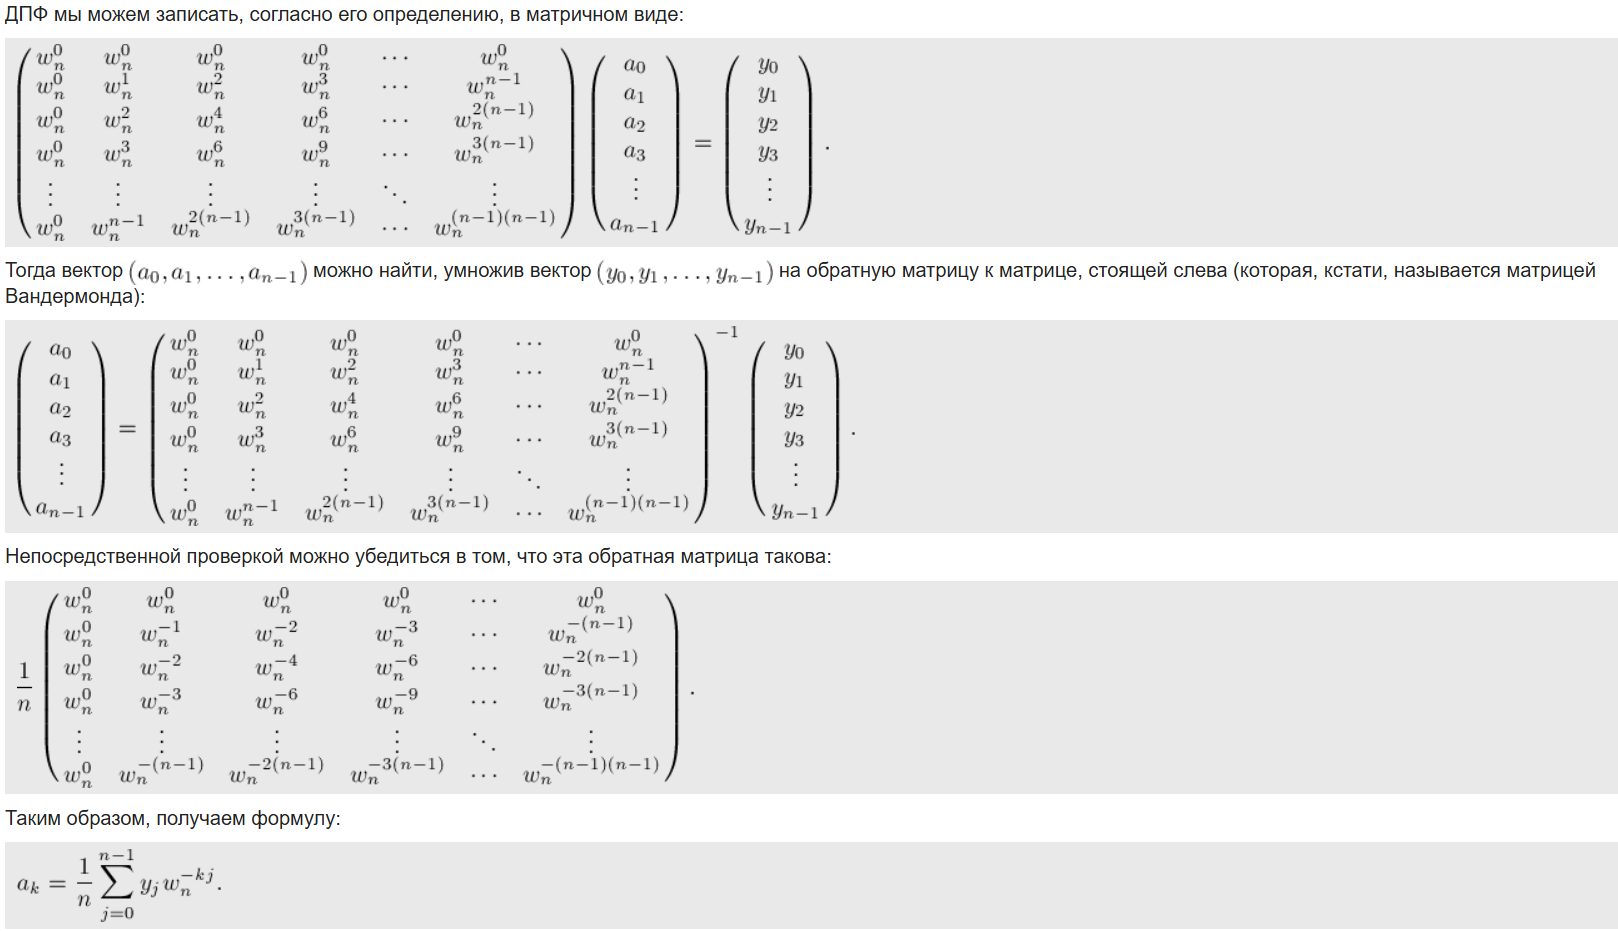

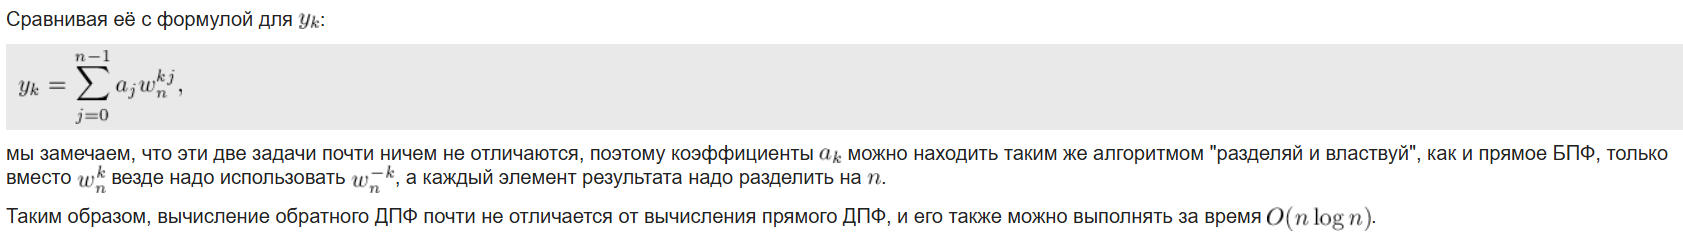

In [6]:
import math
import cmath

def fft_recursive_fixed(x, inverse=False):
    """
    Рекурсивная реализация БПФ.
    Правильная рекурсия с битовой инверсией.
    """
    n = len(x)

    if n == 1:
        return x

    if n & (n - 1) != 0:
        raise ValueError("Длина массива должна быть степенью двойки")

    # Правильное разделение: четные и нечетные индексы
    even = fft_recursive_fixed(x[0::2], inverse)
    odd = fft_recursive_fixed(x[1::2], inverse)

    result = [0] * n

    # Поворачивающие множители
    for k in range(n // 2):
        # Прямое БПФ: exp(-2πi * k / n)
        # Обратное БПФ: exp(2πi * k / n)
        if inverse:
            angle = 2 * math.pi * k / n
        else:
            angle = -2 * math.pi * k / n

        # Комплексная экспонента: cos(angle) + i*sin(angle)
        w = complex(math.cos(angle), math.sin(angle))

        # Операция "бабочка"
        result[k] = even[k] + w * odd[k]
        result[k + n // 2] = even[k] - w * odd[k]

    # Для обратного БПФ делим на n
    if inverse:
        result = [x / n for x in result]

    return result


def bit_reverse_copy(x):
    """
    Перестановка элементов в порядке битовой инверсии.
    Это необходимо для итеративной реализации, но для рекурсивной
    порядок должен быть правильным из-за способа разделения.
    """
    n = len(x)
    # Находим количество бит
    bits = n.bit_length() - 1

    result = [0] * n
    for i in range(n):
        # Битовый реверс
        rev = 0
        for j in range(bits):
            if i & (1 << j):
                rev |= 1 << (bits - 1 - j)
        result[rev] = x[i]

    return result


def fft_iterative(x, inverse=False):
    """
    ИТЕРАТИВНАЯ реализация БПФ.
    Использует битовую инверсию и итеративную бабочку.
    """
    n = len(x)

    if n & (n - 1) != 0:
        raise ValueError("Длина массива должна быть степенью двойки")

    # Биговая инверсия
    # Находим количество бит
    bits = n.bit_length() - 1

    # Создаем массив с битовой инверсией
    result = [0] * n
    for i in range(n):
        # Вычисляем битовый реверс
        rev = 0
        for j in range(bits):
            if i & (1 << j):
                rev |= 1 << (bits - 1 - j)
        result[rev] = x[i]

    # Итеративное БПФ
    length = 2
    while length <= n:
        # Поворачивающий множитель для текущей длины
        if inverse:
            angle = 2 * math.pi / length
        else:
            angle = -2 * math.pi / length

        wlen = complex(math.cos(angle), math.sin(angle))

        for i in range(0, n, length):
            w = 1 + 0j
            for j in range(i, i + length // 2):
                u = result[j]
                v = result[j + length // 2] * w

                result[j] = u + v
                result[j + length // 2] = u - v

                w *= wlen

        length <<= 1

    # Для обратного БПФ делим на n
    if inverse:
        result = [x / n for x in result]

    return result


def multiply_polynomials_fft(poly1, poly2):
    """
    Умножение многочленов через БПФ (итеративная версия).
    """
    result_size = len(poly1) + len(poly2) - 1

    # Находим ближайшую степень двойки
    n = 1
    while n < result_size:
        n <<= 1

    # Создаем комплексные массивы
    a = [complex(poly1[i] if i < len(poly1) else 0, 0) for i in range(n)]
    b = [complex(poly2[i] if i < len(poly2) else 0, 0) for i in range(n)]

    # Прямое БПФ
    A = fft_iterative(a, inverse=False)
    B = fft_iterative(b, inverse=False)

    # Поэлементное умножение
    C = [A[i] * B[i] for i in range(n)]

    # Обратное БПФ
    result_complex = fft_iterative(C, inverse=True)

    # Округление
    result = []
    for i in range(result_size):
        val = result_complex[i].real
        # Округляем до ближайшего целого
        rounded = int(round(val))
        # Дополнительная проверка из-за погрешностей
        if abs(val - rounded) > 0.1:
            # Если значение далеко от целого, возможно, это ошибка
            print(f"Предупреждение: result[{i}] = {val} далеко от целого")
        result.append(rounded)

    return result


def test_fft_implementation():
    """Тестирование различных реализаций БПФ."""

    print("=" * 70)
    print("ТЕСТИРОВАНИЕ ИТЕРАТИВНОЙ ВЕРСИИ БПФ")
    print("=" * 70)

    # Тест 1: Базовый тест с импульсом
    print("\n1. Тест с импульсным сигналом:")
    test_signal = [1.0, 0.0, 0.0, 0.0]
    print(f"   Вход: {test_signal}")

    fft_result = fft_iterative(test_signal, inverse=False)
    print(f"   БПФ: {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_result]}")

    ifft_result = fft_iterative(fft_result, inverse=True)
    print(f"   Обратное БПФ: {[f'{x.real:.2f}' for x in ifft_result]}")

    # Проверка восстановления
    success = all(abs(ifft_result[i].real - test_signal[i]) < 1e-6
                  for i in range(len(test_signal)))
    print(f"   Восстановление: {'✓' if success else '✗'}")

    # Тест 2: Умножение многочленов
    print("\n2. Умножение многочленов [1,2,3] * [4,5]:")

    poly1 = [1, 2, 3]
    poly2 = [4, 5]

    result = multiply_polynomials_fft(poly1, poly2)
    print(f"   Результат: {result}")

    expected = [4, 13, 22, 15]
    print(f"   Ожидалось: {expected}")

    if result == expected:
        print("   ✓ УСПЕХ!")
    else:
        print("   ✗ ОШИБКА!")

    # Тест 3: Все тестовые случаи
    print("\n3. Полное тестирование:")

    test_cases = [
        ([1, 2, 3], [4, 5], [4, 13, 22, 15]),
        ([1, 1], [1, -1], [1, 0, -1]),
        ([1, 2], [3, 4], [3, 10, 8]),
        ([1, 0, 1], [1, 0, 1], [1, 0, 2, 0, 1]),
        ([1, 1, 1, 1], [1, 1], [1, 2, 2, 2, 1]),
        ([5], [1, 2, 3], [5, 10, 15]),
    ]

    all_passed = True
    for i, (p1, p2, expected) in enumerate(test_cases, 1):
        result = multiply_polynomials_fft(p1, p2)

        # Наивное умножение для двойной проверки
        naive = [0] * (len(p1) + len(p2) - 1)
        for j in range(len(p1)):
            for k in range(len(p2)):
                naive[j + k] += p1[j] * p2[k]

        if result == expected and result == naive:
            print(f"   ✓ Тест {i}: {p1} * {p2} = {result}")
        else:
            print(f"   ✗ Тест {i}: {p1} * {p2}")
            print(f"       БПФ: {result}")
            print(f"       Ожидалось: {expected}")
            print(f"       Наивно: {naive}")
            all_passed = False

    if all_passed:
        print("\n🎉 ВСЕ ТЕСТЫ ПРОЙДЕНЫ! 🎉")
    else:
        print("\n⚠️ Некоторые тесты не пройдены")


def manual_fft_4_working(x):
    """
    Рабочая реализация БПФ для N=4 для проверки.
    """
    # БПФ для N=2
    def fft_2(x):
        return [x[0] + x[1], x[0] - x[1]]

    # Разделяем на четные и нечетные
    even = [x[0], x[2]]
    odd = [x[1], x[3]]

    # Вычисляем БПФ для половин
    E = fft_2(even)
    O = fft_2(odd)

    # Объединяем
    result = [0, 0, 0, 0]
    # Корни для N=4
    w0 = 1 + 0j
    w1 = -1j  # exp(-πi/2)
    w2 = -1 + 0j  # exp(-πi)
    w3 = 1j  # exp(-3πi/2)

    result[0] = E[0] + w0 * O[0]
    result[1] = E[1] + w1 * O[0]
    result[2] = E[0] + w2 * O[1]
    result[3] = E[1] + w3 * O[1]

    return result


def compare_implementations():
    """Сравнение разных реализаций БПФ."""

    print("\n" + "=" * 70)
    print("СРАВНЕНИЕ РЕАЛИЗАЦИЙ")
    print("=" * 70)

    test_signal = [1.0, 2.0, 3.0, 4.0]

    print(f"\nТестовый сигнал: {test_signal}")

    # Наша итеративная реализация
    fft_iter = fft_iterative(test_signal, inverse=False)
    print(f"\nИтеративная БПФ: {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_iter]}")

    # Ручная реализация для N=4
    fft_manual = manual_fft_4_working(test_signal)
    print(f"Ручная БПФ (N=4): {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_manual]}")

    # NumPy для проверки
    import numpy as np
    fft_numpy = np.fft.fft(test_signal)
    print(f"NumPy БПФ:       {[f'{x.real:.2f}{x.imag:+.2f}j' for x in fft_numpy]}")

    # Проверка итеративной реализации с NumPy
    diff = max(abs(fft_iter[i] - fft_numpy[i]) for i in range(len(test_signal)))
    print(f"\nМаксимальная разница с NumPy: {diff:.2e}")

    if diff < 1e-6:
        print("✓ Итеративная реализация работает корректно!")
    else:
        print("✗ Итеративная реализация имеет ошибки")


if __name__ == "__main__":
    # Запускаем тесты
    test_fft_implementation()
    compare_implementations()

    # Дополнительный тест с пошаговой демонстрацией
    print("\n" + "=" * 70)
    print("ДЕМОНСТРАЦИЯ УМНОЖЕНИЯ МНОГОЧЛЕНОВ")
    print("=" * 70)

    poly1 = [1, 2, 3]
    poly2 = [4, 5]

    print(f"\nМногочлен A: {poly1}")
    print(f"Многочлен B: {poly2}")

    result = multiply_polynomials_fft(poly1, poly2)

    # Форматируем вывод
    def polynomial_to_string(coeffs):
        terms = []
        for i, coeff in enumerate(coeffs):
            if coeff != 0:
                if i == 0:
                    terms.append(f"{coeff}")
                elif i == 1:
                    terms.append(f"{coeff}x")
                else:
                    terms.append(f"{coeff}x^{i}")
        return " + ".join(terms) if terms else "0"

    print(f"\n({polynomial_to_string(poly1)}) * ({polynomial_to_string(poly2)})")
    print(f"= {polynomial_to_string(result)}")

    # Проверка
    expected = [4, 13, 22, 15]
    if result == expected:
        print("\n✓ Результат правильный!")
    else:
        print(f"\n✗ Ошибка! Результат: {result}, ожидалось: {expected}")

ТЕСТИРОВАНИЕ ИТЕРАТИВНОЙ ВЕРСИИ БПФ

1. Тест с импульсным сигналом:
   Вход: [1.0, 0.0, 0.0, 0.0]
   БПФ: ['1.00+0.00j', '1.00+0.00j', '1.00+0.00j', '1.00+0.00j']
   Обратное БПФ: ['1.00', '0.00', '0.00', '0.00']
   Восстановление: ✓

2. Умножение многочленов [1,2,3] * [4,5]:
   Результат: [4, 13, 22, 15]
   Ожидалось: [4, 13, 22, 15]
   ✓ УСПЕХ!

3. Полное тестирование:
   ✓ Тест 1: [1, 2, 3] * [4, 5] = [4, 13, 22, 15]
   ✓ Тест 2: [1, 1] * [1, -1] = [1, 0, -1]
   ✓ Тест 3: [1, 2] * [3, 4] = [3, 10, 8]
   ✓ Тест 4: [1, 0, 1] * [1, 0, 1] = [1, 0, 2, 0, 1]
   ✓ Тест 5: [1, 1, 1, 1] * [1, 1] = [1, 2, 2, 2, 1]
   ✓ Тест 6: [5] * [1, 2, 3] = [5, 10, 15]

🎉 ВСЕ ТЕСТЫ ПРОЙДЕНЫ! 🎉

СРАВНЕНИЕ РЕАЛИЗАЦИЙ

Тестовый сигнал: [1.0, 2.0, 3.0, 4.0]

Итеративная БПФ: ['10.00+0.00j', '-2.00+2.00j', '-2.00+0.00j', '-2.00-2.00j']
Ручная БПФ (N=4): ['10.00+0.00j', '-2.00-6.00j', '6.00+0.00j', '-2.00-2.00j']
NumPy БПФ:       ['10.00+0.00j', '-2.00+2.00j', '-2.00+0.00j', '-2.00-2.00j']

Максимальная разница